#  Training Experiments

Compare three DeepLabCut training strategies:

1. Combined model with Cam1 + Cam2 in one project.
2. Sequential transfer: Cam1 -> Cam2.
3. Sequential transfer: Cam2 -> Cam1.

## 1. Set Up Notebook Environment
Import modules, print versions, and initialize reproducibility.

In [7]:
import os
import glob
import json
import logging
import random
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import cv2
import re

import deeplabcut
import xrommtools


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Seed: {SEED}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"DeepLabCut: {deeplabcut.__version__}")

Seed: 42
NumPy: 1.23.5
Pandas: 2.3.3
DeepLabCut: 3.0.0rc13


## 2. Define Configuration and Constants
Centralize all paths and training parameters here.

In [3]:
# Workspace-relative root (adjust only if notebook is moved)
ROOT = Path("..")

# Existing single-camera project configs
CAM1_CONFIG = ROOT / "DeepLabCut" / "Miguel" / "TestData" / "Canari_cam1_training" / "Canari-Tyler-2026-03-31" / "config.yaml"
CAM2_CONFIG = ROOT / "DeepLabCut" / "Miguel" / "TestData" / "Canari_cam2_training" / "Canari-Tyler-2026-03-31" / "config.yaml"

# New combined project destination
COMBINED_PROJECT_ROOT = ROOT / "DeepLabCut" / "Miguel" / "TestData" / "Canari_combined_training"
TASK = "Canari"
EXPERIMENTER = "Tyler"

# Source folder containing XMA-style training data folders
DATA_PATH = ROOT / "DeepLabCut" / "Miguel" / "trainingdata"
DATASET_NAME = "Canari"
NFRAMES = 800

# Use a fixed seed so random frame sampling for the combined model is reproducible.
# Set to None if you want different random frames each run.
COMBINED_FRAME_SELECTION_SEED = SEED

# Dummy videos used only for project creation
DUMMY_VIDEO_CAM1 = ROOT / "DeepLabCut" / "Miguel" / "trainingdata" / "Miguel_20250816_F6" / "MiguelF6_20250816_Cam1_short.avi"
DUMMY_VIDEO_CAM2 = ROOT / "DeepLabCut" / "Miguel" / "trainingdata" / "Miguel_20250816_F6" / "MiguelF6_20250816_Cam2_short.avi"

# Evaluation videos
TEST_VIDEO_CAM1 = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "Miguel20260401Trial6_Cam1" / "MiguelF6_20250816_Cam1_short.avi"
TEST_VIDEO_CAM2 = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "Miguel20260401Trial6_Cam2" / "MiguelF6_20250816_Cam2_short.avi"

EPOCHS_SMOKE = 20
EPOCHS_FULL = 200

# Safety toggles
RUN_TRAINING = False
RUN_VIDEO_ANALYSIS = False
USE_FULL_EPOCHS = False

print("Configs loaded")
print("Cam1:", CAM1_CONFIG)
print("Cam2:", CAM2_CONFIG)
print("Combined root:", COMBINED_PROJECT_ROOT)

Configs loaded
Cam1: ..\DeepLabCut\Miguel\TestData\Canari_cam1_training\Canari-Tyler-2026-03-31\config.yaml
Cam2: ..\DeepLabCut\Miguel\TestData\Canari_cam2_training\Canari-Tyler-2026-03-31\config.yaml
Combined root: ..\DeepLabCut\Miguel\TestData\Canari_combined_training


## 3. Implement Core Functions
Helper utilities plus experiment runners for combined and sequential training.

In [ ]:
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("tyler-training")




@dataclass
class ExperimentResult:
    """Container for one experiment run outcome.

    Attributes
    ----------
    name : str
        Experiment identifier.
    config_used : str
        Config file used for final model/evaluation.
    init_snapshot : str
        Snapshot used for model weight initialization (or marker such as "fresh").
    trained : bool
        True if training was executed.
    analyzed : bool
        True if video analysis was executed.
    notes : str
        Additional details, usually latest snapshot path or dry-run reason.
    """

    name: str
    config_used: str
    init_snapshot: str
    trained: bool
    analyzed: bool
    notes: str


# Utility functions for path handling and validation

def as_posix_str(path_obj: Path) -> str:
    """Return an absolute, forward-slash path string.

    Parameters
    ----------
    path_obj : Path
        Input path to normalize.

    Returns
    -------
    str
        Absolute path string with '/' separators.
    """
    return str(path_obj.resolve()).replace("\\", "/")


def validate_path_exists(path_obj: Path, label: str) -> None:
    """Validate that a path exists.

    Parameters
    ----------
    path_obj : Path
        Path to verify.
    label : str
        Human-readable label used in the error message.

    Raises
    ------
    FileNotFoundError
        If the path does not exist.
    """
    if not path_obj.exists():
        raise FileNotFoundError(f"Missing {label}: {path_obj}")


def get_project_dir_from_config(config_path: Path) -> Path:
    """Get the DeepLabCut project directory from a config path.

    Parameters
    ----------
    config_path : Path
        Path to a DeepLabCut config.yaml file.

    Returns
    -------
    Path
        Parent directory that contains the project config.
    """
    return config_path.parent


# Config and snapshot helpers

def find_latest_snapshot(config_path: Path) -> str:
    """Find the latest PyTorch snapshot for a given project.

    Parameters
    ----------
    config_path : Path
        Path to the project config.yaml.

    Returns
    -------
    str
        Full path to the most recent snapshot-*.pt file.

    Raises
    ------
    FileNotFoundError
        If no snapshots match the expected pattern.
    """
    project_dir = get_project_dir_from_config(config_path)
    pattern = project_dir / "dlc-models-pytorch" / "iteration-0" / "*" / "train" / "snapshots" / "snapshot-*.pt"
    snapshots = sorted(glob.glob(as_posix_str(pattern)))
    if not snapshots:
        raise FileNotFoundError(f"No snapshots found under pattern: {pattern}")
    return snapshots[-1]


def load_bodyparts(config_path: Path):
    """Load bodyparts list from a DeepLabCut config.

    Parameters
    ----------
    config_path : Path
        Path to the config.yaml file.

    Returns
    -------
    list
        Bodyparts list from config, or an empty list if missing.
    """
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
    return cfg.get("bodyparts", [])


def get_available_scorers(config_path: Path) -> list[str]:
    """Return scorer names discovered in labeled-data H5 files.

    Parameters
    ----------
    config_path : Path
        DeepLabCut config path.

    Returns
    -------
    list[str]
        Unique scorer names found in MultiIndex level 0.
    """
    project_dir = get_project_dir_from_config(config_path)
    scorer_set = set()
    for h5_path in project_dir.glob("labeled-data/*/CollectedData_*.h5"):
        try:
            df = pd.read_hdf(as_posix_str(h5_path))
        except Exception:
            continue
        if isinstance(df.columns, pd.MultiIndex) and df.columns.nlevels > 0:
            scorer_values = [str(v) for v in df.columns.get_level_values(0).unique()]
            scorer_set.update([v for v in scorer_values if v and v.lower() != "nan"])
    return sorted(scorer_set)


def ensure_config_scorer_matches_data(config_path: Path) -> str | None:
    """Sync config scorer with labeled-data scorer if needed.

    Parameters
    ----------
    config_path : Path
        DeepLabCut config path to inspect and possibly update.

    Returns
    -------
    str | None
        Scorer used after sync, or None if none found in data.
    """
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)

    available = get_available_scorers(config_path)
    if not available:
        logger.warning("No scorer found in labeled-data for %s", config_path)
        return None

    current = str(cfg.get("scorer", "")).strip()
    if current in available:
        return current

    chosen = available[0]
    cfg["scorer"] = chosen
    with open(config_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    logger.warning("Updated scorer in %s from '%s' to '%s'", config_path, current, chosen)
    return chosen


def assert_bodyparts_match(config_a: Path, config_b: Path) -> None:
    """Ensure two projects share the same bodyparts ordering.

    Parameters
    ----------
    config_a : Path
        First project config path.
    config_b : Path
        Second project config path.

    Raises
    ------
    ValueError
        If the bodyparts lists differ.
    """
    bodyparts_a = load_bodyparts(config_a)
    bodyparts_b = load_bodyparts(config_b)
    if bodyparts_a != bodyparts_b:
        raise ValueError("Bodyparts mismatch between configs; snapshot transfer would be invalid.")


# Project and data creation

def create_combined_project_if_missing() -> Path:
    """Create or reuse a combined-camera DeepLabCut project.

    Returns
    -------
    Path
        Path to the combined project config.yaml.

    Raises
    ------
    FileNotFoundError
        If the required dummy video path is missing.
    """
    validate_path_exists(DUMMY_VIDEO_CAM1, "dummy video cam1")
    COMBINED_PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

    existing = sorted(COMBINED_PROJECT_ROOT.glob(f"{TASK}-{EXPERIMENTER}-*/config.yaml"))
    if existing:
        logger.info("Using existing combined config: %s", existing[-1])
        return existing[-1]

    try:
        config_path = deeplabcut.create_new_project(
            TASK,
            EXPERIMENTER,
            [as_posix_str(DUMMY_VIDEO_CAM1)],
            as_posix_str(COMBINED_PROJECT_ROOT),
            copy_videos=False,
        )
    except TypeError:
        # Fallback for DLC builds expecting 'project' keyword instead of positional args.
        config_path = deeplabcut.create_new_project(
            project=TASK,
            experimenter=EXPERIMENTER,
            videos=[as_posix_str(DUMMY_VIDEO_CAM1)],
            working_directory=as_posix_str(COMBINED_PROJECT_ROOT),
            copy_videos=False,
        )

    logger.info("Created combined project: %s", config_path)
    return Path(config_path)


def build_combined_dataset(combined_config: Path) -> None:
    """Populate combined project labeled-data from XMA data.

    Parameters
    ----------
    combined_config : Path
        Config path for the combined project.

    Notes
    -----
    Uses xrommtools.xma_to_dlc with nnetworks=1 so both cameras are
    included in one dataset.

    Raises
    ------
    FileNotFoundError
        If DATA_PATH does not exist.
    """
    validate_path_exists(DATA_PATH, "training data path")

    prev_random_state = random.getstate()
    try:
        if COMBINED_FRAME_SELECTION_SEED is not None:
            random.seed(COMBINED_FRAME_SELECTION_SEED)
            logger.info(
                "Combined frame sampling seed set to %s",
                COMBINED_FRAME_SELECTION_SEED,
            )

        xrommtools.xma_to_dlc(
            as_posix_str(combined_config),
            as_posix_str(DATA_PATH),
            DATASET_NAME,
            EXPERIMENTER,
            NFRAMES,
            nnetworks=1,
        )
    finally:
        random.setstate(prev_random_state)


def require_bodyparts_review_before_training(run_training: bool) -> None:
    """Prompt for manual bodyparts review before training starts.

    Parameters
    ----------
    run_training : bool
        If False, skip prompt.

    Raises
    ------
    RuntimeError
        If user does not explicitly confirm bodyparts were reviewed.
    """
    if not run_training:
        print("Bodyparts checkpoint skipped because RUN_TRAINING is False.")
        return

    combined_config = create_combined_project_if_missing()
    config_paths = [CAM1_CONFIG, CAM2_CONFIG, combined_config]

    print("\nPlease review bodyparts in these config files before training:")
    for cfg in config_paths:
        validate_path_exists(cfg, f"config {cfg.name}")
        parts = load_bodyparts(cfg)
        print(f"- {cfg}")
        print(f"  bodyparts count: {len(parts)}")
        print(f"  first five: {parts[:5]}")

    print("\nAfter editing config bodyparts, re-run this cell and confirm below.")
    ack = input("Type exactly 'CONFIRMED BODYPARTS' to confirm: ").strip()
    if ack != "CONFIRMED BODYPARTS":
        raise RuntimeError("Training stopped. Update config bodyparts and confirm with the exact phrase.")

    print("Bodyparts confirmation accepted. Training can proceed.")
    
# Training

def create_and_train(config_path: Path, epochs: int, snapshot_path: str | None = None) -> str:
    """Create training dataset and run model training.

    Parameters
    ----------
    config_path : Path
        Project config.yaml path.
    epochs : int
        Number of training epochs.
    snapshot_path : str | None, optional
        Snapshot used to initialize training. If None, training starts fresh.

    Returns
    -------
    str
        Path to latest snapshot after training.

    Notes
    -----
    Automatically synchronizes config scorer to labeled-data scorer
    before calling create_training_dataset.
    """
    ensure_config_scorer_matches_data(config_path)
    deeplabcut.create_training_dataset(as_posix_str(config_path))
    if snapshot_path is None:
        deeplabcut.train_network(as_posix_str(config_path), epochs=epochs)
    else:
        deeplabcut.train_network(
            as_posix_str(config_path),
            epochs=epochs,
            snapshot_path=snapshot_path,
        )
    return find_latest_snapshot(config_path)


# Evaluation and analysis

def run_eval_bundle(config_path: Path, videos: list[Path], run_analysis: bool) -> bool:
    """Run evaluation and optional video analysis outputs.

    Parameters
    ----------
    config_path : Path
        Project config.yaml path.
    videos : list[Path]
        Videos to analyze when run_analysis is True.
    run_analysis : bool
        Whether to run analyze_videos, create_labeled_video, and
        plot_trajectories.

    Returns
    -------
    bool
        True if analysis ran, False if evaluation-only mode.
    """
    #deeplabcut.evaluate_network(as_posix_str(config_path))
    if not run_analysis:
        return False

    for video_path in videos:
        validate_path_exists(video_path, f"test video {video_path.name}")
        deeplabcut.analyze_videos(
            as_posix_str(config_path),
            [as_posix_str(video_path)],
            destfolder=as_posix_str(video_path.parent),
        )
        deeplabcut.create_labeled_video(
            as_posix_str(config_path),
            [as_posix_str(video_path)],
            videotype=".avi",
            destfolder=as_posix_str(video_path.parent),
        )
        deeplabcut.plot_trajectories(
            as_posix_str(config_path),
            [as_posix_str(video_path)],
            videotype=".avi",
            destfolder=as_posix_str(video_path.parent),
        )
    return True


def run_combined_experiment(epochs: int, run_training: bool, run_analysis: bool) -> ExperimentResult:
    """Run the unified Cam1+Cam2 experiment.

    Parameters
    ----------
    epochs : int
        Number of training epochs.
    run_training : bool
        If True, perform dataset build and training.
    run_analysis : bool
        If True, run post-training video analysis bundle.

    Returns
    -------
    ExperimentResult
        Structured status for this experiment.
    """
    combined_config = create_combined_project_if_missing()

    if run_training:
        build_combined_dataset(combined_config)
        latest = create_and_train(combined_config, epochs=epochs)
        analyzed = run_eval_bundle(combined_config, [TEST_VIDEO_CAM1, TEST_VIDEO_CAM2], run_analysis)
        return ExperimentResult(
            name="combined_cam1_cam2",
            config_used=as_posix_str(combined_config),
            init_snapshot="fresh",
            trained=True,
            analyzed=analyzed,
            notes=f"Latest snapshot: {latest}",
        )

    return ExperimentResult(
        name="combined_cam1_cam2",
        config_used=as_posix_str(combined_config),
        init_snapshot="fresh",
        trained=False,
        analyzed=False,
        notes="Dry run only. Set RUN_TRAINING=True to execute.",
    )


## 4. Create a Minimal Test Harness
These checks validate helper behavior before expensive training.

In [4]:
# Basic path conversion test
sample = Path("a") / "b" / "c.txt"
assert isinstance(as_posix_str(sample), str)

# Config consistency test (only if both files exist)
if CAM1_CONFIG.exists() and CAM2_CONFIG.exists():
    bp1 = load_bodyparts(CAM1_CONFIG)
    bp2 = load_bodyparts(CAM2_CONFIG)
    assert isinstance(bp1, list)
    assert isinstance(bp2, list)
    print(f"Bodyparts lengths: cam1={len(bp1)}, cam2={len(bp2)}")
else:
    print("Skipping bodyparts test because one or both configs are missing.")

print("Minimal harness checks passed.")

Bodyparts lengths: cam1=21, cam2=21
Minimal harness checks passed.


## 5. Run Example Execution
This cell runs all three experiment pipelines in dry-run mode by default.

In [5]:
# Safety toggles
RUN_TRAINING = True
RUN_VIDEO_ANALYSIS = True
USE_FULL_EPOCHS = True

### Bodyparts Review Checkpoint
Before training, review and edit `bodyparts` in each config as needed. This checkpoint will require explicit confirmation.

In [9]:
epochs = EPOCHS_FULL if USE_FULL_EPOCHS else EPOCHS_SMOKE

require_bodyparts_review_before_training(RUN_TRAINING)

summary_df = run_combined_experiment(
    epochs=epochs,
    run_training=RUN_TRAINING,
    run_analysis=RUN_VIDEO_ANALYSIS,
)

print(f"Run mode: {'FULL' if USE_FULL_EPOCHS else 'SMOKE'}")
print(f"Training enabled: {RUN_TRAINING}")
print(f"Video analysis enabled: {RUN_VIDEO_ANALYSIS}")
summary_df

INFO | Using existing combined config: ..\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\config.yaml



Please review bodyparts in these config files before training:
- ..\DeepLabCut\Miguel\TestData\Canari_cam1_training\Canari-Tyler-2026-03-31\config.yaml
  bodyparts count: 21
  first five: ['Cranium_Right_Anterior', 'Cranium_Left_Anterior', 'Cranium_Right_Posterior', 'Cranium_Right_Middle', 'Cranium_Left_Posterior']
- ..\DeepLabCut\Miguel\TestData\Canari_cam2_training\Canari-Tyler-2026-03-31\config.yaml
  bodyparts count: 21
  first five: ['Cranium_Right_Anterior', 'Cranium_Left_Anterior', 'Cranium_Right_Posterior', 'Cranium_Right_Middle', 'Cranium_Left_Posterior']
- ..\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\config.yaml
  bodyparts count: 21
  first five: ['Cranium_Right_Anterior', 'Cranium_Left_Anterior', 'Cranium_Right_Posterior', 'Cranium_Right_Middle', 'Cranium_Left_Posterior']

After editing config bodyparts, re-run this cell and confirm below.


INFO | Using existing combined config: ..\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\config.yaml
INFO | Combined frame sampling seed set to 42


Bodyparts confirmation accepted. Training can proceed.
Extracting camera 1 trial images and 2D points...
Extracting camera 2 trial images and 2D points...


INFO | Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


...done.
Training data extracted to projectpath/labeled-data. Now use deeplabcut.create_training_dataset
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\labeled-data\MiguelF6_20250816_Cam1_short\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\Miguel\\TestData\\Canari_combined_training\\Canari-Tyler-2026-04-01\\labeled-data\\Canari', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\Miguel\\TestData\\Canari_combined_training\\Canari-Tyler-2026-04-01\\labeled-data\\MiguelF6_20250816_Cam1_short']
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\TestDa

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\dlc-models-pytorch\iteration-0\CanariApr1-trainset95shuffle1\train\pytorch_config.yaml
  bo

FileNotFoundError: No snapshots found under pattern: ..\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\dlc-models-pytorch\iteration-0\*\train\snapshots\snapshot-*.pt

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\dlc-models-pytorch\iteration-0\CanariApr1-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariApr1shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\Miguel20260401Trial6_Cam1\MiguelF6_20250816_Cam1_short.avi
Video metadata: 
  Overall # of frames:    980
  Duration of video [s]:  1.31
  fps:                    750.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 980/980 [00:27<00:00, 36.13it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\all_in_1\MiguelF6_20250816_Cam1_shortDLC_Resnet50_CanariApr1shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\all_in_1\MiguelF6_20250816_Cam1_shortDLC_Resnet50_CanariApr1shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Starting to process video: C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/Miguel20260401Trial6_Cam1/MiguelF6_20250816_Cam1_short.avi
Loading C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN

100%|██████████| 980/980 [00:06<00:00, 160.31it/s]


Loading  C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/Miguel20260401Trial6_Cam1/MiguelF6_20250816_Cam1_short.avi and data.
Plots created! Please check the directory "plot-poses" within the video directory
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\dlc-models-pytorch\iteration-0\CanariApr1-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariApr1shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\Miguel20260401Trial6_Cam2\MiguelF6_20250816_Cam2_short.avi
Video metadata: 
  Overall # of frames:    980
  Duration of video [s]:  1.31
  fps:                    750.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 980/980 [00:27<00:00, 36.07it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\all_in_1\MiguelF6_20250816_Cam2_shortDLC_Resnet50_CanariApr1shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\all_in_1\MiguelF6_20250816_Cam2_shortDLC_Resnet50_CanariApr1shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Starting to process video: C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/Miguel20260401Trial6_Cam2/MiguelF6_20250816_Cam2_short.avi
Loading C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN

100%|██████████| 980/980 [00:10<00:00, 91.90it/s]


Loading  C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/Miguel20260401Trial6_Cam2/MiguelF6_20250816_Cam2_short.avi and data.
Plots created! Please check the directory "plot-poses" within the video directory


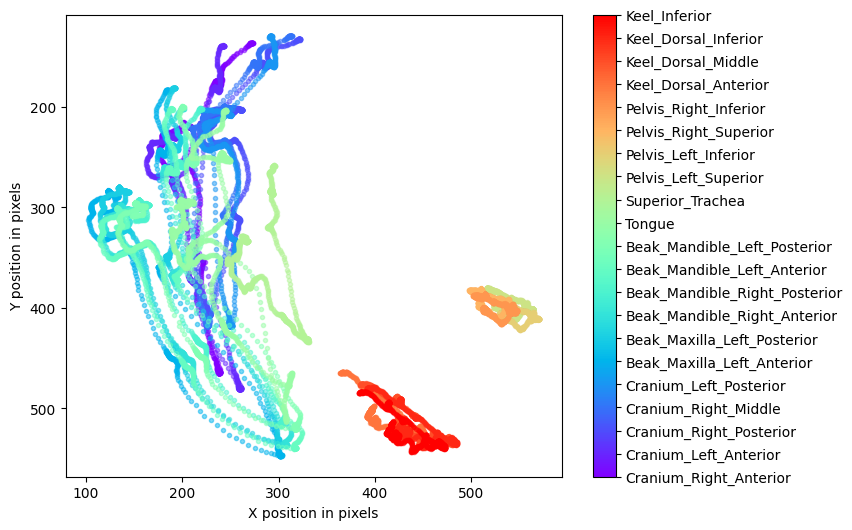

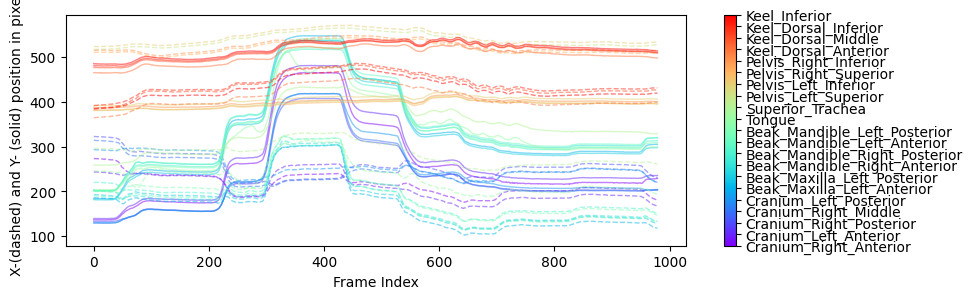

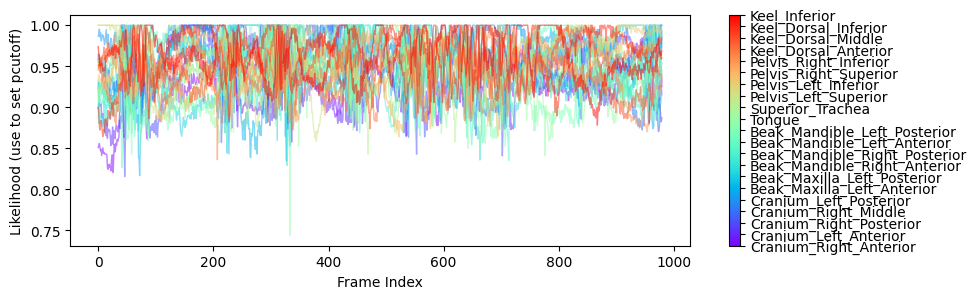

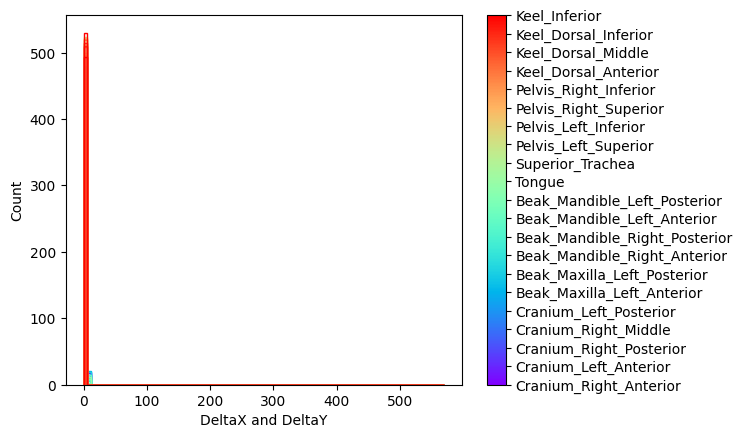

In [17]:
# Run video analysis on the combined model and plot trajectories for both test videos

COMBINED_CONFIG = ROOT / "DeepLabCut" / "Miguel" / "TestData" / "Canari_combined_training" / "Canari-Tyler-2026-04-01" / "config.yaml"
video1_path = TEST_VIDEO_CAM1
video2_path = TEST_VIDEO_CAM2
dest_folder = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "combined_models" / "all_in_1"
if RUN_VIDEO_ANALYSIS:
    validate_path_exists(COMBINED_CONFIG, "combined config")
    validate_path_exists(video1_path, "test video cam1")
    validate_path_exists(video2_path, "test video cam2")

#    deeplabcut.evaluate_network(COMBINED_CONFIG)
    for video_path in [video1_path, video2_path]:
        deeplabcut.analyze_videos(
            as_posix_str(COMBINED_CONFIG),
            [as_posix_str(video_path)],
            destfolder=as_posix_str(dest_folder),
        )
        deeplabcut.create_labeled_video(
            as_posix_str(COMBINED_CONFIG),
            [as_posix_str(video_path)],
            videotype=".avi",
            destfolder=as_posix_str(dest_folder),
        )
        deeplabcut.plot_trajectories(
            as_posix_str(COMBINED_CONFIG),
            [as_posix_str(video_path)],
            videotype=".avi",
            destfolder=as_posix_str(dest_folder),
        )

In [33]:
import cv2
import re

In [31]:
def _to_uint8_bgr(frame):
    """Convert any TIFF frame to uint8 BGR for OpenCV VideoWriter."""
    if frame is None:
        raise ValueError("Encountered unreadable frame.")

    # Normalize to uint8 if source is not already 8-bit.
    if frame.dtype != np.uint8:
        frame = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    if frame.ndim == 2:
        return cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

    if frame.ndim == 3 and frame.shape[2] == 4:
        return cv2.cvtColor(frame, cv2.COLOR_BGRA2BGR)

    if frame.ndim == 3 and frame.shape[2] == 3:
        return frame

    raise ValueError("Unsupported frame shape: %s" % (frame.shape,))


def tiff_stack_to_avi(input_folder, output_path, fps=500, fourcc="MJPG", sort_numeric=True):
    """Convert a folder of TIFF frames into an AVI file.

    Parameters
    ----------
    input_folder : str
        Folder containing .tif/.tiff frames.
    output_path : str
        Full path to output AVI.
    fps : int, optional
        Frames per second for output video.
    fourcc : str, optional
        FourCC codec string (e.g., "MJPG", "XVID").
    sort_numeric : bool, optional
        If True, sort using the last numeric token in filenames when present.

    Returns
    -------
    dict
        Conversion summary including output path and frame count.
    """
    if not os.path.isdir(input_folder):
        raise FileNotFoundError("Input folder not found: %s" % input_folder)

    tif_files = [
        os.path.join(input_folder, name)
        for name in os.listdir(input_folder)
        if name.lower().endswith((".tif", ".tiff"))
    ]
    if not tif_files:
        raise FileNotFoundError("No .tif or .tiff files found in: %s" % input_folder)

    if sort_numeric:
        def _sort_key(path):
            name = os.path.basename(path)
            match = re.search(r"(\d+)(?!.*\d)", name)
            if match:
                return (0, int(match.group(1)), name.lower())
            return (1, name.lower())

        tif_files = sorted(tif_files, key=_sort_key)
    else:
        tif_files = sorted(tif_files)

    first_frame = _to_uint8_bgr(cv2.imread(tif_files[0], cv2.IMREAD_UNCHANGED))
    height, width = first_frame.shape[:2]

    output_dir = os.path.dirname(output_path)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*fourcc),
        float(fps),
        (width, height),
        True,
    )
    if not writer.isOpened():
        raise RuntimeError("Could not open VideoWriter for output: %s" % output_path)

    frames_written = 0
    try:
        for tif_path in tif_files:
            frame = _to_uint8_bgr(cv2.imread(tif_path, cv2.IMREAD_UNCHANGED))
            if frame.shape[:2] != (height, width):
                raise ValueError(
                    "Frame size mismatch in %s. Expected %sx%s, got %sx%s."
                    % (tif_path, width, height, frame.shape[1], frame.shape[0])
                )
            writer.write(frame)
            frames_written += 1
    finally:
        writer.release()

    return {
        "output_path": output_path,
        "frames_written": frames_written,
        "fps": fps,
        "codec": fourcc,
        "width": width,
        "height": height,
    }


In [40]:
# Convert Cam3 TIFF stack to AVI
TIFF_STACK_DIR = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "Miguel20260401Trial6_Cam3" / "deeper" / "20786 - (Slave)_F6_4987 - CopyUND"
OUTPUT_OOD_AVI = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "Miguel20260401Trial6_Cam3" / "OOD-tester-filtered.avi"

conversion_summary = tiff_stack_to_avi(
    input_folder=as_posix_str(TIFF_STACK_DIR),
    output_path=as_posix_str(OUTPUT_OOD_AVI),
    fps=750,
    fourcc="MJPG",
)

print("TIFF stack conversion complete")
print(conversion_summary)

TIFF stack conversion complete
{'output_path': 'C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/Miguel20260401Trial6_Cam3/OOD-tester-filtered.avi', 'frames_written': 2630, 'fps': 750, 'codec': 'MJPG', 'width': 768, 'height': 768}


In [23]:
# Run video analysis on the combined model and plot trajectories for both test videos

COMBINED_CONFIG = ROOT / "DeepLabCut" / "Miguel" / "TestData" / "Canari_combined_training" / "Canari-Tyler-2026-04-01" / "config.yaml"
 
OOD_Video = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "Miguel20260401Trial6_Cam3" / "OOD-tester.avi"
dest_folder = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "combined_models" / "all_in_1"
if RUN_VIDEO_ANALYSIS:
    validate_path_exists(COMBINED_CONFIG, "combined config")
    validate_path_exists(OOD_Video, "OOD test video")

#    deeplabcut.evaluate_network(COMBINED_CONFIG)

deeplabcut.analyze_videos(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    destfolder=as_posix_str(dest_folder),
)
deeplabcut.create_labeled_video(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    videotype=".avi",
    destfolder=as_posix_str(dest_folder),
)
deeplabcut.plot_trajectories(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    videotype=".avi",
    destfolder=as_posix_str(dest_folder),
)

ValueError: nframes is bigger than number of detected frames

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\dlc-models-pytorch\iteration-0\CanariApr1-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariApr1shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing3\OOD-tester-effort.avi
Video metadata: 
  Overall # of frames:    2630
  Duration of video [s]:  3.51
  fps:                    750.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2630/2630 [01:14<00:00, 35.23it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing3\OOD-tester-effortDLC_Resnet50_CanariApr1shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing3\OOD-tester-effortDLC_Resnet50_CanariApr1shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Starting to process video: C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/combined_models/OOD-Testing3/OOD-tester-effort.avi
Loading C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Mi

100%|██████████| 2630/2630 [00:28<00:00, 90.75it/s] 


Loading  C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/combined_models/OOD-Testing3/OOD-tester-effort.avi and data.
Plots created! Please check the directory "plot-poses" within the video directory


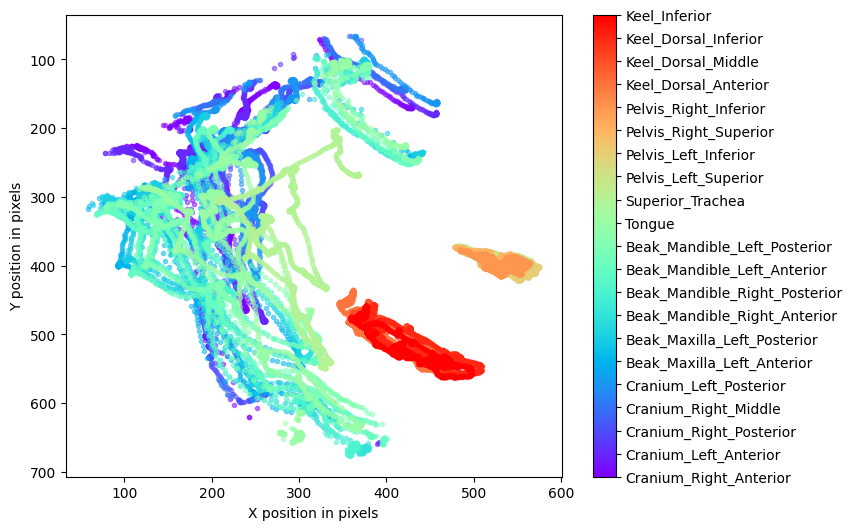

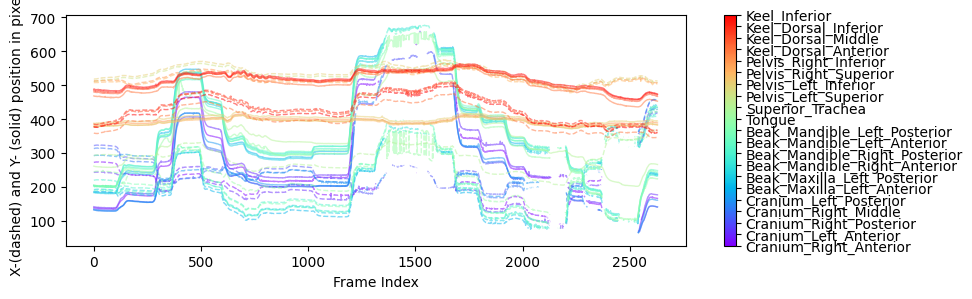

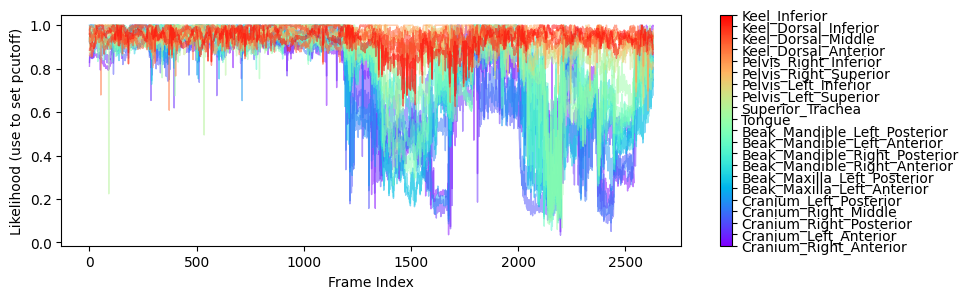

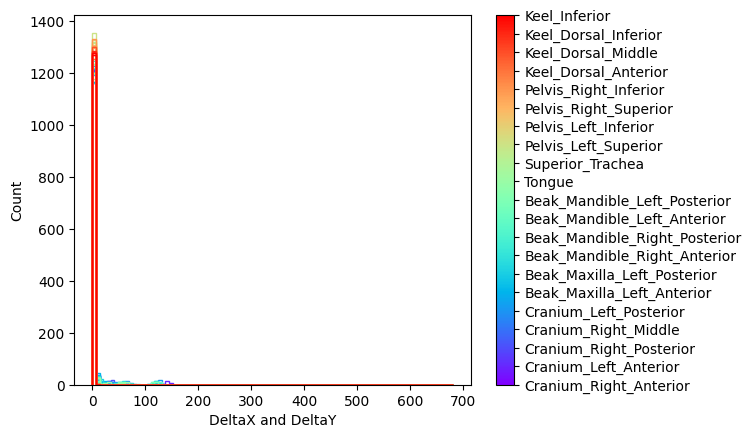

In [42]:
# Run video analysis on the combined model and plot trajectories for both test videos

COMBINED_CONFIG = ROOT / "DeepLabCut" / "Miguel" / "TestData" / "Canari_combined_training" / "Canari-Tyler-2026-04-01" / "config.yaml"
 
OOD_Video = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "combined_models" / "OOD-Testing3" / "OOD-tester-effort.avi"
dest_folder = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "combined_models" / "OOD-Testing3"
if RUN_VIDEO_ANALYSIS:
    validate_path_exists(COMBINED_CONFIG, "combined config")
    validate_path_exists(OOD_Video, "OOD test video")

deeplabcut.analyze_videos(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    destfolder=as_posix_str(dest_folder),
)
deeplabcut.create_labeled_video(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    videotype=".avi",
    destfolder=as_posix_str(dest_folder),
)
deeplabcut.plot_trajectories(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    videotype=".avi",
    destfolder=as_posix_str(dest_folder),
)

In [9]:
# Convert Cam3 TIFF stack to AVI
TIFF_STACK_DIR = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "Miguel20260401Trial6_Cam3" / "deeper" / "20789 - (Master_F2_4980UND"
OUTPUT_OOD_AVI = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "Miguel20260401Trial6_Cam3" / "OOD-tester-aug2.avi"

conversion_summary = tiff_stack_to_avi(
    input_folder=as_posix_str(TIFF_STACK_DIR),
    output_path=as_posix_str(OUTPUT_OOD_AVI),
    fps=500,
    fourcc="MJPG",
)

print("TIFF stack conversion complete")
print(conversion_summary)

TIFF stack conversion complete
{'output_path': 'C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/Miguel20260401Trial6_Cam3/OOD-tester-aug2.avi', 'frames_written': 848, 'fps': 500, 'codec': 'MJPG', 'width': 768, 'height': 768}


Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\dlc-models-pytorch\iteration-0\CanariApr1-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariApr1shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing4-cam1\OOD-tester-aug2.avi
Video metadata: 
  Overall # of frames:    848
  Duration of video [s]:  1.70
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 848/848 [00:23<00:00, 36.03it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing4-cam1\OOD-tester-aug2DLC_Resnet50_CanariApr1shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing4-cam1\OOD-tester-aug2DLC_Resnet50_CanariApr1shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Starting to process video: C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/combined_models/OOD-Testing4-cam1/OOD-tester-aug2.avi
Loading C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/Deep

100%|██████████| 848/848 [00:05<00:00, 152.29it/s]


Loading  C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/combined_models/OOD-Testing4-cam1/OOD-tester-aug2.avi and data.
Plots created! Please check the directory "plot-poses" within the video directory


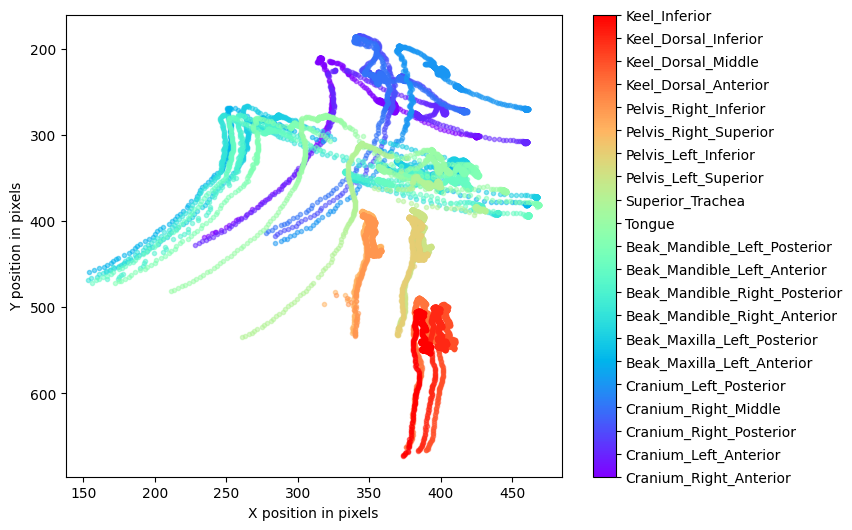

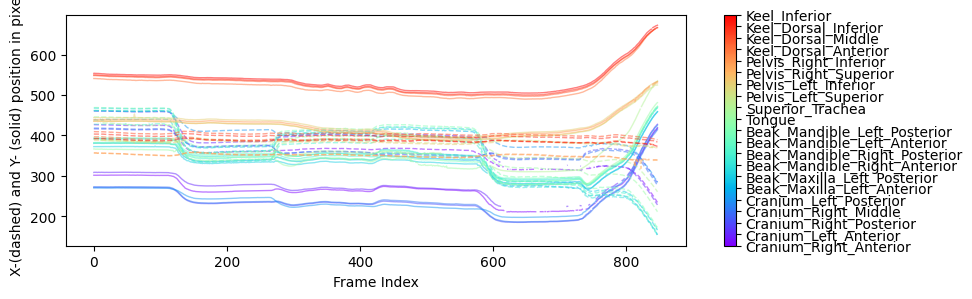

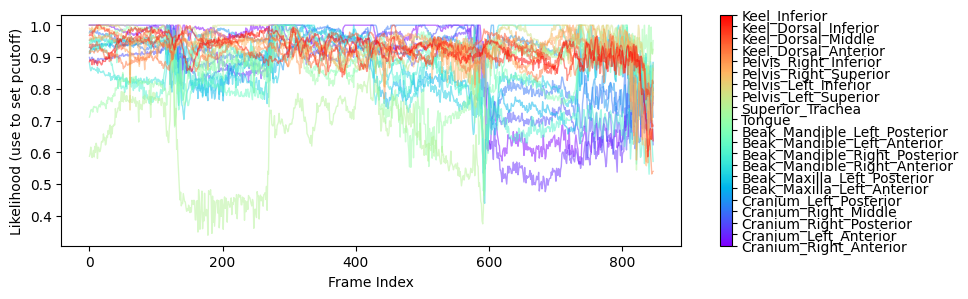

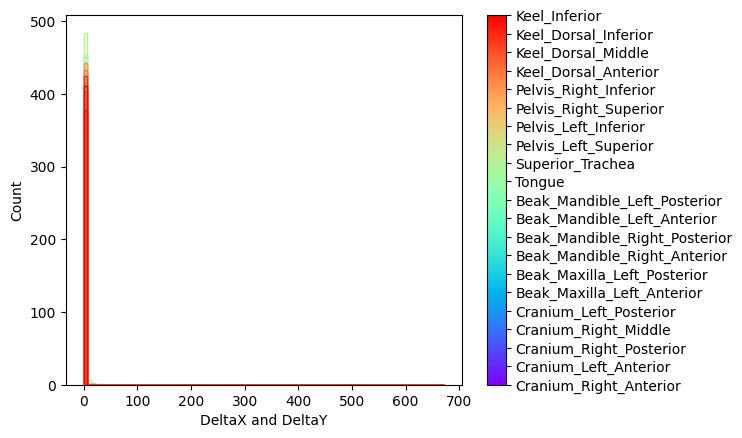

In [10]:
# Run video analysis on the combined model and plot trajectories for both test videos

COMBINED_CONFIG = ROOT / "DeepLabCut" / "Miguel" / "TestData" / "Canari_combined_training" / "Canari-Tyler-2026-04-01" / "config.yaml"
 
OOD_Video = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "combined_models" / "OOD-Testing4-cam1" / "OOD-tester-aug2.avi"
dest_folder = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "combined_models" / "OOD-Testing4-cam1"
if RUN_VIDEO_ANALYSIS:
    validate_path_exists(COMBINED_CONFIG, "combined config")
    validate_path_exists(OOD_Video, "OOD test video")

deeplabcut.analyze_videos(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    destfolder=as_posix_str(dest_folder),
)
deeplabcut.create_labeled_video(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    videotype=".avi",
    destfolder=as_posix_str(dest_folder),
)
deeplabcut.plot_trajectories(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    videotype=".avi",
    destfolder=as_posix_str(dest_folder),
)

In [29]:
deeplabcut.analyze_videos(config= COMBINED_CONFIG, 
                          videos=[r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing3-tocsv\OOD-tester-effort.avi"], 
                          destfolder= r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing3-tocsv",
                          save_as_csv=True)

Analyzing videos with ..\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\dlc-models-pytorch\iteration-0\CanariApr1-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariApr1shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing3-tocsv\OOD-tester-effort.avi
Video metadata: 
  Overall # of frames:    2630
  Duration of video [s]:  3.51
  fps:                    750.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2630/2630 [01:14<00:00, 35.42it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing3-tocsv\OOD-tester-effortDLC_Resnet50_CanariApr1shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Miguel\newdata\combined_models\OOD-Testing3-tocsv\OOD-tester-effortDLC_Resnet50_CanariApr1shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_CanariApr1shuffle1_snapshot_200'

In [31]:

cam1csv = ROOT / "DeepLabCut" / "Miguel" / "newdata" / "combined_models" / "OOD-Testing3-tocsv" / "OOD-tester-effortDLC_Resnet50_CanariApr1shuffle1_snapshot_200.csv"
cam1csv = as_posix_str(cam1csv)

In [35]:
xrommtools.dlc_to_xma(
    cam1data= cam1csv,
    cam2data= cam1csv,
    savepath= as_posix_str(ROOT / "DeepLabCut" / "Miguel" / "newdata" / "combined_models" / "OOD-Testing3-tocsv" / "xma_ready"),
    trialname= "OOD-tester-effort"
)

In [ ]:
deeplabcut.extract_outlier_frames(COMBINED_CONFIG, [as_posix_str(OOD_Video)], destfolder=as_posix_str(dest_folder), videotype=".avi", outlieralgorithm="fitting")

In [ ]:
deeplabcut.evaluate_network(COMBINED_CONFIG, plotting=True)

Evaluation scorer: DLC_Resnet50_CanariApr1shuffle1_snapshot_200


100%|██████████| 80/80 [00:02<00:00, 37.04it/s]


HDF5ExtError: HDF5 error back trace

  File "D:\bld\hdf5_1717586849786\work\src\H5F.c", line 660, in H5Fcreate
    unable to synchronously create file
  File "D:\bld\hdf5_1717586849786\work\src\H5F.c", line 614, in H5F__create_api_common
    unable to create file
  File "D:\bld\hdf5_1717586849786\work\src\H5VLcallback.c", line 3605, in H5VL_file_create
    file create failed
  File "D:\bld\hdf5_1717586849786\work\src\H5VLcallback.c", line 3571, in H5VL__file_create
    file create failed
  File "D:\bld\hdf5_1717586849786\work\src\H5VLnative_file.c", line 94, in H5VL__native_file_create
    unable to create file
  File "D:\bld\hdf5_1717586849786\work\src\H5Fint.c", line 1852, in H5F_open
    unable to open file: name = '..\DeepLabCut\Miguel\TestData\Canari_combined_training\Canari-Tyler-2026-04-01\evaluation-results-pytorch\iteration-0\CanariApr1-trainset95shuffle1\DLC_Resnet50_CanariApr1shuffle1_snapshot_200.h5', tent_flags = 13
  File "D:\bld\hdf5_1717586849786\work\src\H5FD.c", line 

In [23]:
deeplabcut.filterpredictions(
    COMBINED_CONFIG,
    [as_posix_str(OOD_Video)],  
    videotype=".avi",
    filtertype="arima",
    ARdegree=5,
    MAdegree=2,
    destfolder=as_posix_str(dest_folder)
)

Filtering with arima model C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/combined_models/OOD-Testing4-cam1/OOD-tester-aug2.avi
Data from OOD-tester-aug2 were already filtered. Skipping...


Loading  C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/combined_models/OOD-Testing4-cam1/OOD-tester-aug2.avi and data.
Plots created! Please check the directory "plot-poses" within the video directory


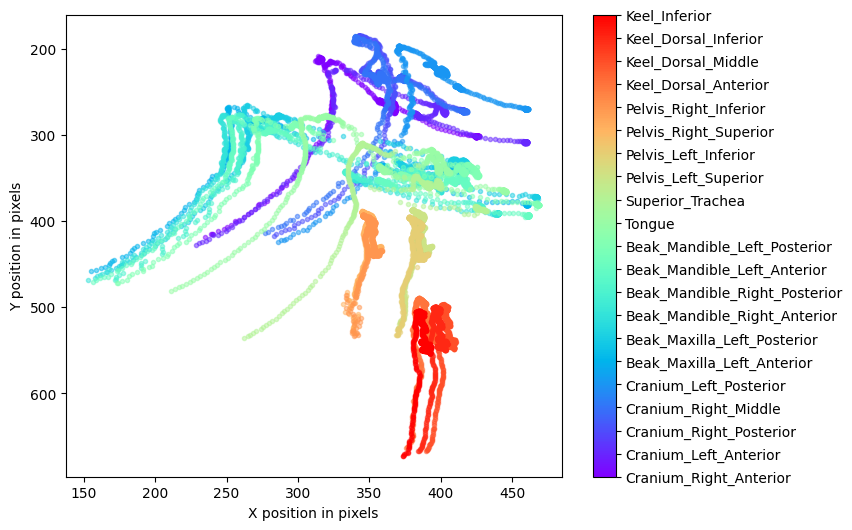

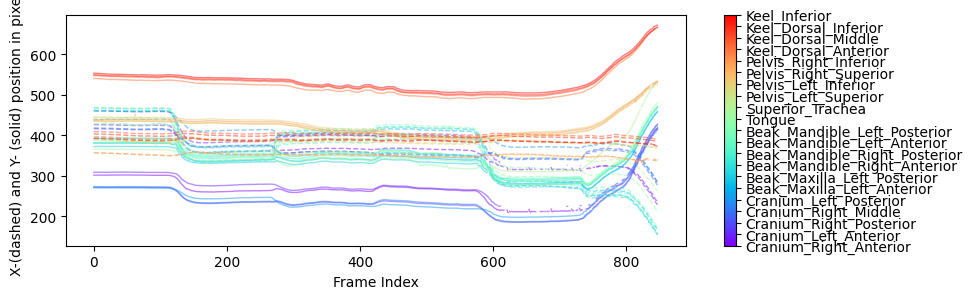

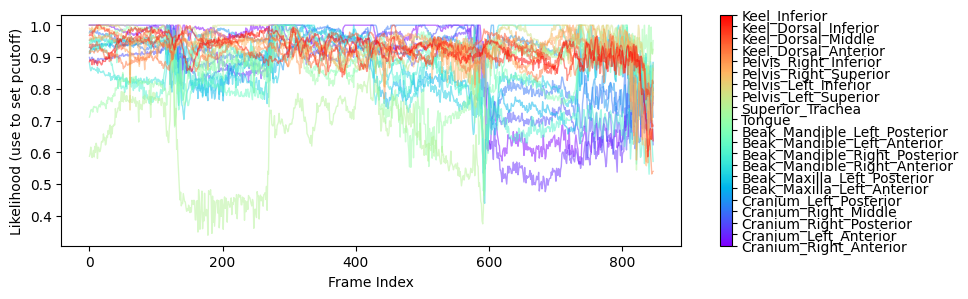

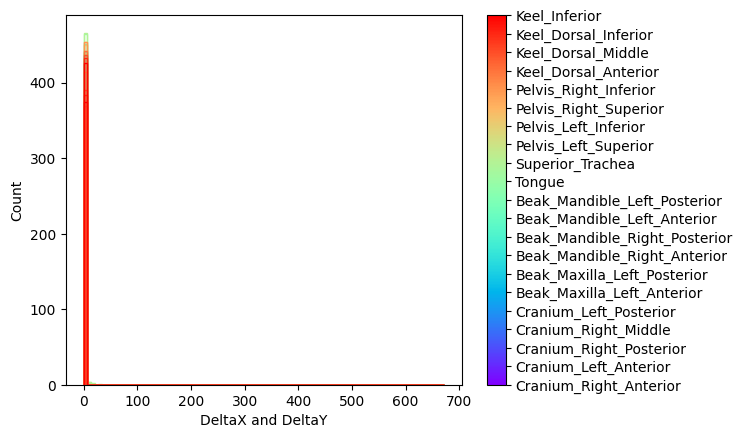

In [24]:
deeplabcut.plot_trajectories(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    videotype=".avi",
    destfolder=as_posix_str(dest_folder),
    filtered=True,
)

In [25]:
deeplabcut.create_labeled_video(
    as_posix_str(COMBINED_CONFIG),
    [as_posix_str(OOD_Video)],
    videotype=".avi",
    destfolder=as_posix_str(dest_folder),
    filtered=True,

)

Starting to process video: C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/combined_models/OOD-Testing4-cam1/OOD-tester-aug2.avi
Loading C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/Miguel/newdata/combined_models/OOD-Testing4-cam1/OOD-tester-aug2.avi and data.
Duration of video [s]: 1.7, recorded with 500 fps!
Overall # of frames: 848 with cropped frame dimensions: 768 768
Generating frames and creating video.


100%|██████████| 848/848 [00:05<00:00, 151.23it/s]


[True]